In [1]:
from spectral import io as envi
from spectral import principal_components
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from spectral.io import envi
from spectral import principal_components

C:\Users\laral\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# hdr_path = r"D:\wenqu\mosaic\site2c\site2c_simulation_mosaic"   # rasterio handles ENVI pairs
out_dir  = r"D:\wenqu\mosaic\PCA"
var_keep = 0.97                     # 98% variance
os.makedirs(out_dir, exist_ok=True)

In [3]:
img = envi.open(
    r"D:\wenqu\multi_ortho\site2c\site2c_multi_or.hdr",
    r"D:\wenqu\multi_ortho\site2c\site2c_multi_or"   # <- use your real extension
)

In [4]:
img.shape

(5470, 4744, 273)

In [6]:
# 2) PCA and reduce by fraction
pc = principal_components(img)            # covariance-based PCA (mean-centered)


Covariance.....done  


C:\Users\laral\AppData\Local\Temp\ipykernel_11740\1981407295.py:2: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  pc = principal_components(img)            # covariance-based PCA (mean-centered)


In [12]:
pc_099 = pc.reduce(fraction=0.99)
img_pc = pc_099.transform(img)

In [13]:

print(img_pc.shape)

(5470, 4744, 3)


In [14]:
pc_k = pc.reduce(fraction=0.99)       # auto-pick k s.t. cumEVR ≥ 0.98
k = pc_k.eigenvalues.shape[0]
print(f"Selected k={k} PCs (≥{var_keep*100:.0f}% EVR)")

Selected k=3 PCs (≥97% EVR)


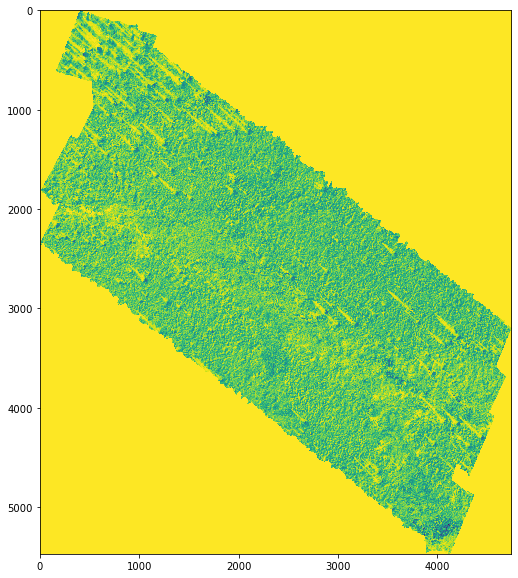

In [15]:
fig = plt.figure(figsize = (10,10))
plt.imshow(img_pc[:,:,0], interpolation='nearest')
plt.show()

In [16]:
b1 = img_pc[:,:,0]
b2 = img_pc[:,:,1]
b3 = img_pc[:,:,2]

In [17]:
import spectral.io.envi as envi
import spectral as spy
import matplotlib.pyplot as plt
from spectral import *
import os 
import pandas as pd
import numpy as np
import rasterio
from rasterio.merge import merge
import glob
from osgeo import gdal, gdalconst 
from osgeo.gdalconst import * 

In [18]:
driver = gdal.GetDriverByName('ENVI')
driver.Register()
inDs = gdal.Open(r"D:\wenqu\multi_ortho\site2c\site2c_multi_or", GA_ReadOnly)

In [19]:
pj = inDs.GetProjection()  ## projection
gt = inDs.GetGeoTransform()  ## geotransform
col = inDs.GetRasterBand(1).XSize
row = inDs.GetRasterBand(1).YSize

In [20]:
driver = gdal.GetDriverByName('GTiff')  ## driver for output file type; "GTiff" for geotiff, "RST" for rst
bands =3
outName = "site2c_pca.tiff"
outPath =r'D:\wenqu\mosaic\PCA'
out_ds = driver.Create(os.path.join(outPath, outName),col,row,bands,gdal.GDT_Float32)

In [21]:
out_ds.GetRasterBand(1).WriteArray(b1)
out_ds.GetRasterBand(2).WriteArray(b2)
out_ds.GetRasterBand(3).WriteArray(b3)

0

In [22]:
out_ds.SetProjection(pj)
out_ds.SetGeoTransform(gt)
del out_ds